# 🎬 The Flop Formula — Notebook B3
## Newsletter Visuals

**Series:** May Newsletter — Movie Intelligence (Bonus Week)
**Prerequisite:** Run Notebooks B1 & B2 first

### Figures produced

| Figure | File | What it shows |
|--------|------|---------------|
| 1 | `flop_fig1_failure_contributions.png` | Which choices drive the disaster — ranked contribution chart |
| 2 | `flop_fig2_profile_vs_population.png` | Where the disaster profile sits vs real films on key dimensions |
| 3 | `flop_fig3_per_model_gauge.png` | Per-model failure probability — the investment memo panel |
| 4 | `flop_fig4_rogues_gallery.png` | The rogues gallery — real films, real consequences |
| 5 | `flop_fig5_feature_radar.png` | Disaster profile radar vs the average successful film |
| 6 | `flop_fig6_failure_distribution.png` | Where the disaster profile sits in the full failure score distribution |


## 0 · Setup

In [3]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

with open("capstone_models.pkl","rb") as f:
    cap = pickle.load(f)
with open("flop_results.pkl","rb") as f:
    flop = pickle.load(f)
with open("flop_analysis.pkl","rb") as f:
    analysis = pickle.load(f)

final_models   = cap["final_models"]
data           = cap["data"]
LABELS         = cap["LABELS"]
MODELS         = list(LABELS.keys())
disaster_vec   = flop["disaster_vec"]
disaster_score = flop["disaster_score"]
profile        = flop["profile"]
worst_choices  = flop["worst_choices"]
m4_feat_names  = flop["m4_feat_names"]
X_ref          = flop["X_ref"]
base_vec       = flop["base_vec"]
contrib_df     = analysis["contrib_df"]
per_model_df   = analysis["per_model_df"]
rogues_full    = analysis["rogues_full"]
base_score     = analysis["base_score"]
meta_test      = analysis["meta_test"]

print(f"✔ Loaded. Disaster score: {disaster_score:.4f}  |  Rogues: {len(rogues_full)}")


✔ Loaded. Disaster score: 0.7075  |  Rogues: 15


## Figure 1 · Failure Contribution Chart

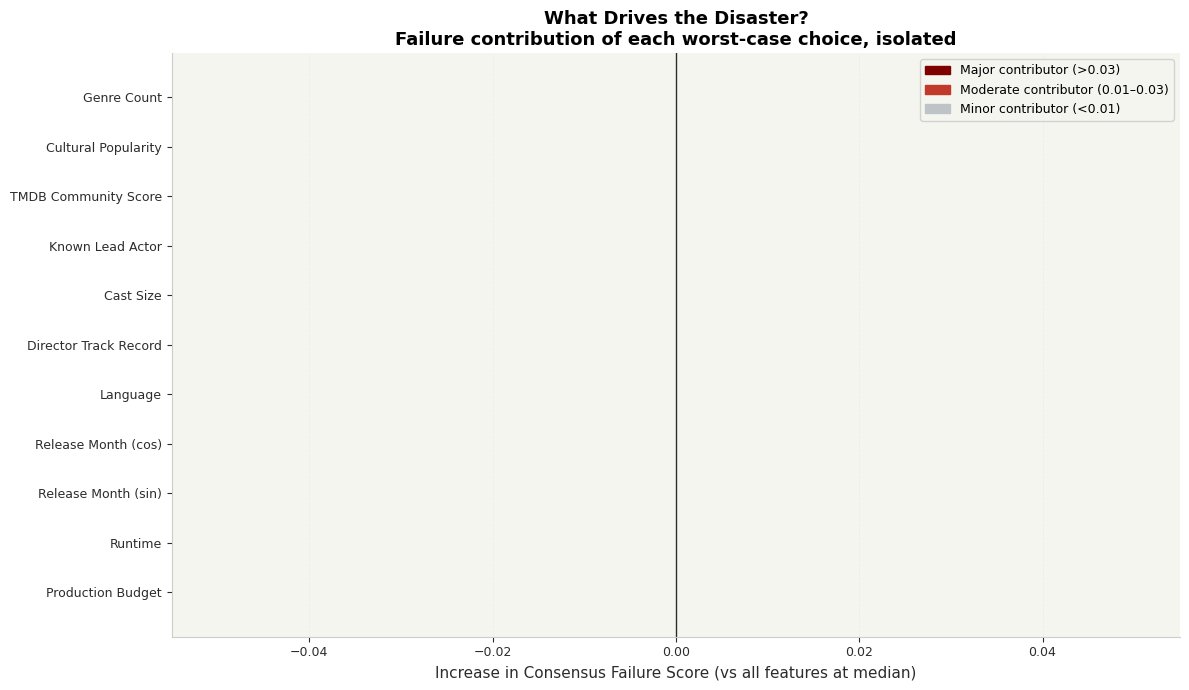

Saved: flop_fig1_failure_contributions.png


In [4]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

# Filter to non-genre features + top genre for readability
non_genre = contrib_df[~contrib_df["feature"].str.startswith("genre_")].copy()
top_genre = contrib_df[contrib_df["feature"].str.startswith("genre_")].nlargest(1,"failure_lift")
plot_df   = pd.concat([non_genre, top_genre]).sort_values("failure_lift").tail(12)

# Clean up feature names for display
name_map = {
    "log_budget"             : "Production Budget",
    "runtime_clean"          : "Runtime",
    "month_sin"              : "Release Month (sin)",
    "month_cos"              : "Release Month (cos)",
    "is_english"             : "Language",
    "genre_count"            : "Genre Count",
    "director_success_score" : "Director Track Record",
    "cast_size_clean"        : "Cast Size",
    "has_known_lead"         : "Known Lead Actor",
    "vote_average_clean"     : "TMDB Community Score",
    "log_popularity"         : "Cultural Popularity",
}
plot_df["label"] = plot_df["feature"].apply(
    lambda x: name_map.get(x, x.replace("genre_","Genre: ").title()))

fig, ax = plt.subplots(figsize=(12, 7))

colors = [DISASTER if v > 0.03 else CRIMSON if v > 0.01 else SILVER
          for v in plot_df["failure_lift"]]
bars = ax.barh(plot_df["label"], plot_df["failure_lift"],
               color=colors, edgecolor="white", linewidth=0.5, height=0.72)

ax.axvline(0, color=DARK_TEXT, linewidth=1)

for bar, val in zip(bars, plot_df["failure_lift"]):
    if abs(val) > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"+{val:.3f}" if val > 0 else f"{val:.3f}",
                va="center", fontsize=8.5, color=DARK_TEXT)

ax.set_xlabel("Increase in Consensus Failure Score (vs all features at median)", fontsize=11)
ax.set_title("What Drives the Disaster?\nFailure contribution of each worst-case choice, isolated",
             fontsize=13, fontweight="bold")

disaster_patch = mpatches.Patch(color=DISASTER, label="Major contributor (>0.03)")
crimson_patch  = mpatches.Patch(color=CRIMSON,  label="Moderate contributor (0.01–0.03)")
silver_patch   = mpatches.Patch(color=SILVER,   label="Minor contributor (<0.01)")
ax.legend(handles=[disaster_patch, crimson_patch, silver_patch],
          fontsize=9, framealpha=0.85)

style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("flop_fig1_failure_contributions.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: flop_fig1_failure_contributions.png")

## Figure 2 · Disaster Profile vs Population

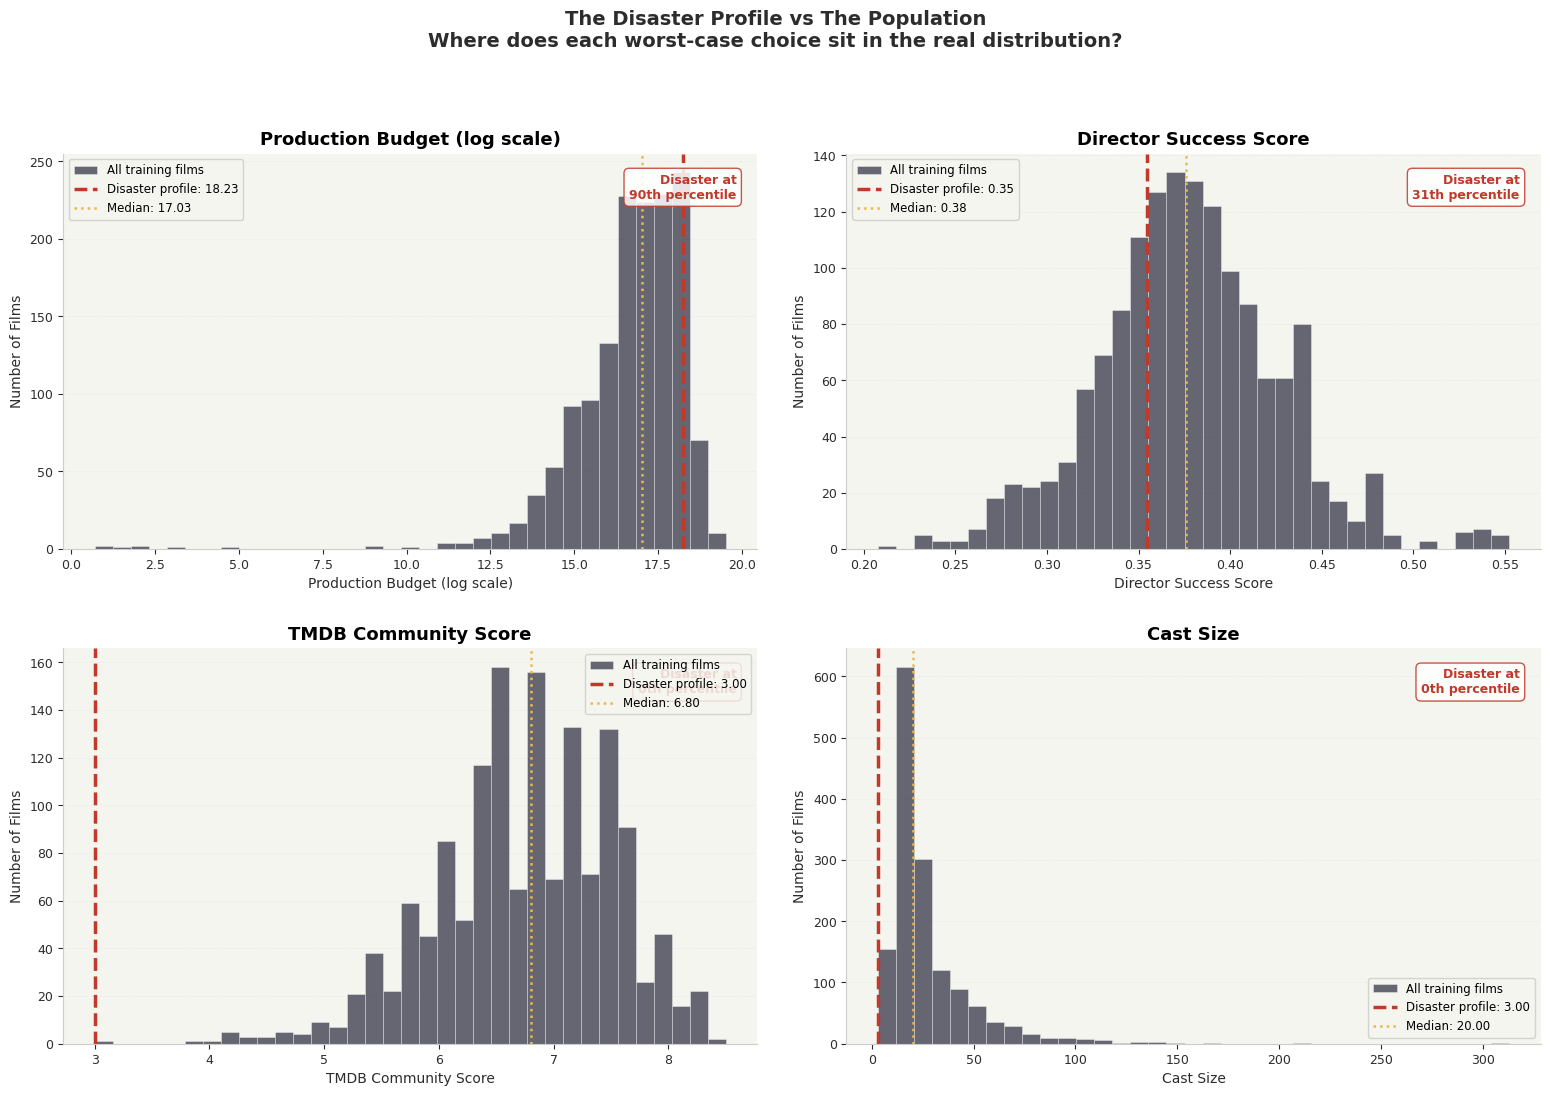

Saved: flop_fig2_profile_vs_population.png


In [6]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

import math

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("""The Disaster Profile vs The Population
Where does each worst-case choice sit in the real distribution?""",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.01)

KEY_FEATS = [
    ("log_budget",             "Production Budget (log scale)", True),
    ("director_success_score", "Director Success Score",        False),
    ("vote_average_clean",     "TMDB Community Score",          False),
    ("cast_size_clean",        "Cast Size",                     False),
]

for ax, (feat, label, is_log) in zip(axes.flatten(), KEY_FEATS):
    idx  = m4_feat_names.index(feat)
    vals = X_ref[:, idx]
    worst_val = disaster_vec[idx]

    ax.hist(vals, bins=35, color=MIDNIGHT, alpha=0.65, edgecolor="white",
            linewidth=0.4, label="All training films")
    ax.axvline(worst_val, color=CRIMSON, linewidth=2.5, linestyle="--",
               label=f"Disaster profile: {worst_val:.2f}")
    ax.axvline(np.median(vals), color=GOLD, linewidth=1.8, linestyle=":",
               label=f"Median: {np.median(vals):.2f}")

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Number of Films", fontsize=10)
    ax.set_title(label)
    ax.legend(fontsize=8.5, framealpha=0.85)
    style_spines(ax)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    # Percentile annotation
    pct = (vals < worst_val).mean() * 100
    ax.text(0.97, 0.95, f"Disaster at\n{pct:.0f}th percentile",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            color=CRIMSON, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=CRIMSON, alpha=0.85))

plt.tight_layout(pad=2.5)
plt.savefig("flop_fig2_profile_vs_population.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: flop_fig2_profile_vs_population.png")

## Figure 3 · Per-Model Failure Gauge Panel

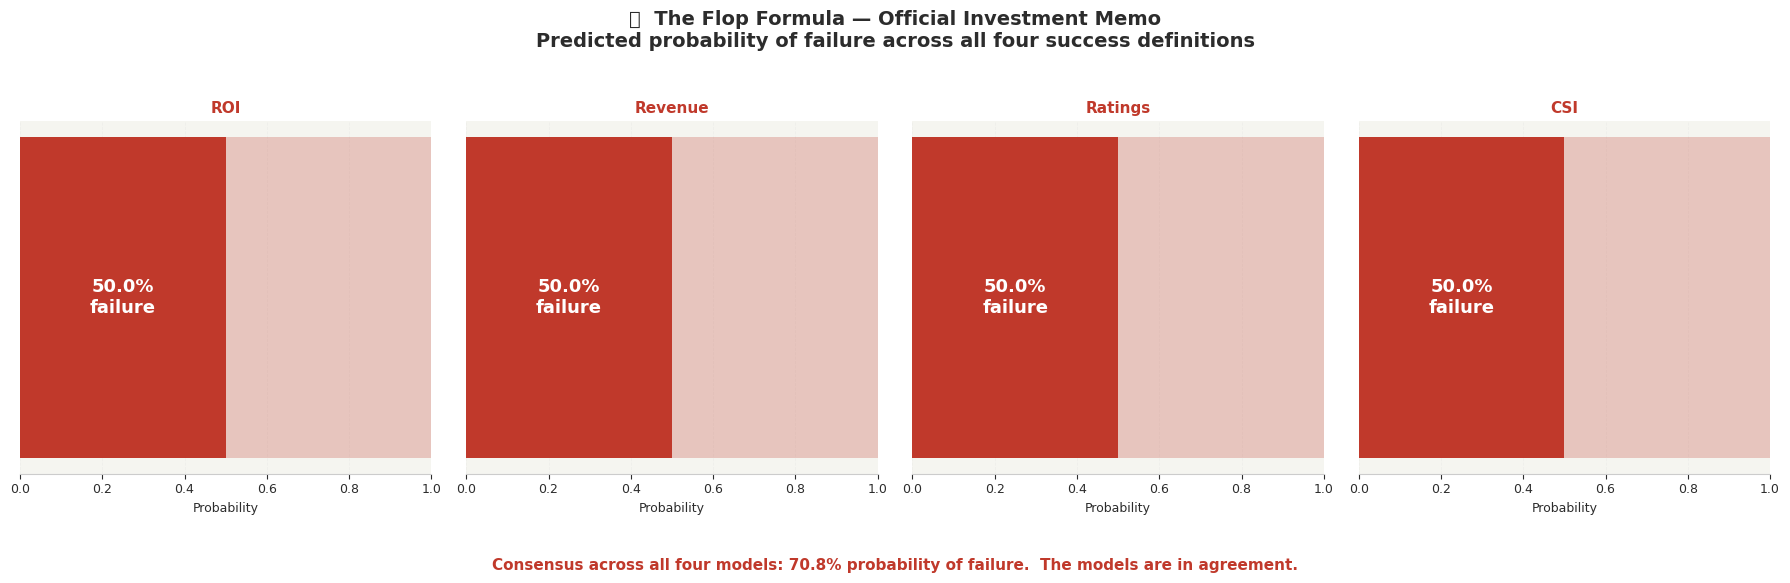

Saved: flop_fig3_per_model_gauge.png


In [8]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

MODEL_COLORS = {
    "M1 — ROI"     : MIDNIGHT,
    "M2 — Revenue" : GOLD,
    "M3 — Ratings" : TEAL,
    "M4 — CSI"     : PURPLE,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("""📋  The Flop Formula — Official Investment Memo
Predicted probability of failure across all four success definitions""",
             fontsize=14, fontweight="bold", color=DARK_TEXT, y=1.04)

for ax, (_, row) in zip(axes, per_model_df.iterrows()):
    model_label = row["Model"]
    fail_prob   = row["Failure prob"]
    color       = MODEL_COLORS.get(model_label, CRIMSON)

    # Horizontal bar gauge
    ax.barh(["Failure"], [fail_prob],       color=CRIMSON,  height=0.45, label="Failure")
    ax.barh(["Failure"], [1 - fail_prob],   color=color,    height=0.45,
            left=[fail_prob], alpha=0.25, label="Success")

    ax.set_xlim(0, 1)
    ax.set_title(model_label, fontsize=11, color=color, fontweight="bold")
    ax.set_xlabel("Probability", fontsize=9)

    # Big percentage label
    ax.text(fail_prob / 2, 0,
            f"{fail_prob*100:.1f}%\nfailure",
            ha="center", va="center", fontsize=13, fontweight="bold",
            color="white")

    style_spines(ax, keep=("bottom",))
    ax.set_yticks([])
    ax.xaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

# Consensus annotation
fig.text(0.5, -0.08,
         f"Consensus across all four models: {disaster_score*100:.1f}% probability of failure."
         f"  The models are in agreement.",
         ha="center", fontsize=11, color=CRIMSON, fontweight="bold")

plt.tight_layout()
plt.savefig("flop_fig3_per_model_gauge.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: flop_fig3_per_model_gauge.png")

## Figure 4 · The Rogues Gallery

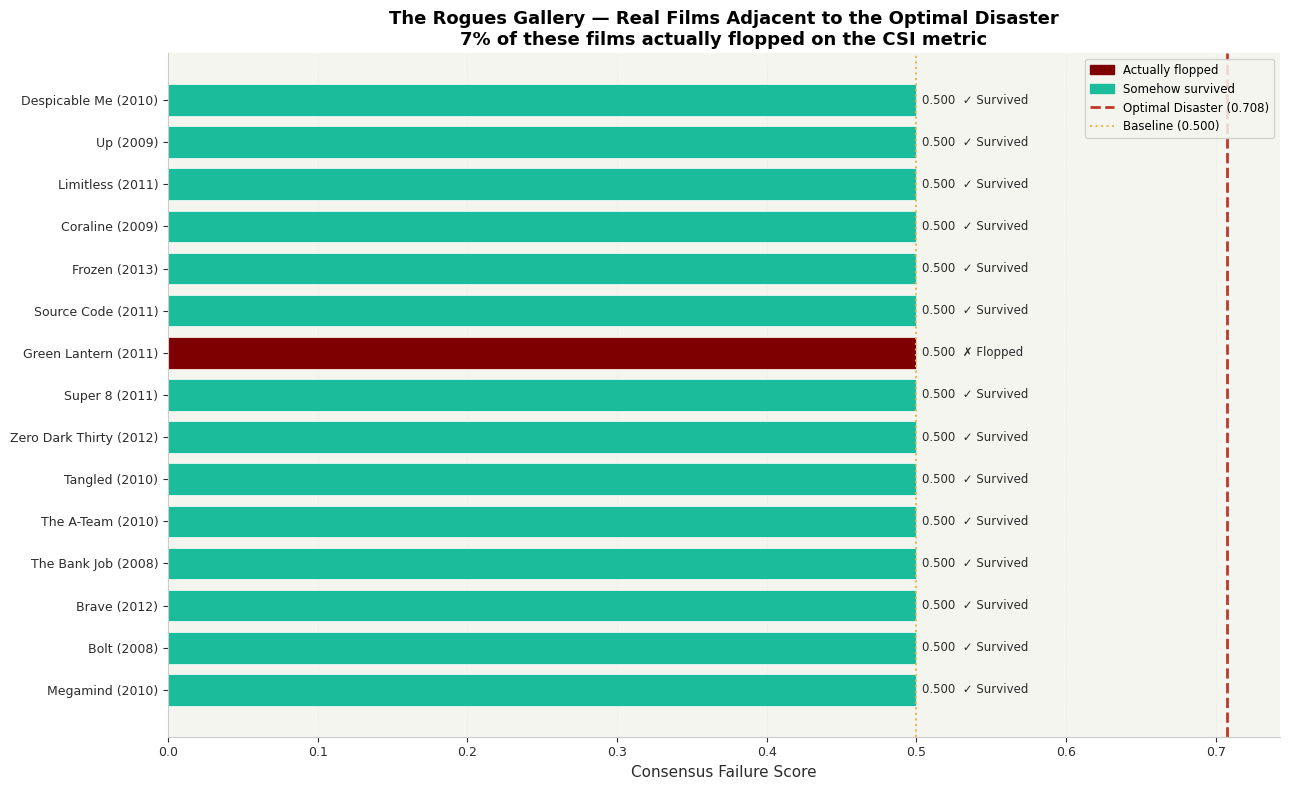

Saved: flop_fig4_rogues_gallery.png


In [10]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(13, 8))

rg = rogues_full.sort_values("failure_score", ascending=True).tail(15)

colors = [DISASTER if r == 0 else TEAL for r in rg["actual_success"]]
bars   = ax.barh(
    [f"{r['title']} ({int(r['release_year'])})" for _, r in rg.iterrows()],
    rg["failure_score"],
    color=colors, edgecolor="white", linewidth=0.5, height=0.75
)

ax.axvline(disaster_score, color=CRIMSON, linewidth=2, linestyle="--",
           label=f"Optimal Disaster Profile ({disaster_score:.3f})")
ax.axvline(base_score,     color=GOLD,    linewidth=1.5, linestyle=":",
           label=f"Population baseline ({base_score:.3f})")

for bar, val, success in zip(bars, rg["failure_score"], rg["actual_success"]):
    outcome = "✗ Flopped" if success == 0 else "✓ Survived"
    ax.text(bar.get_width() + 0.004,
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}  {outcome}",
            va="center", fontsize=8.5, color=DARK_TEXT)

disaster_patch = mpatches.Patch(color=DISASTER, label="Actually flopped")
teal_patch     = mpatches.Patch(color=TEAL,     label="Somehow survived")
ax.legend(handles=[disaster_patch, teal_patch,
                   plt.Line2D([0],[0], color=CRIMSON, linestyle="--", lw=2,
                              label=f"Optimal Disaster ({disaster_score:.3f})"),
                   plt.Line2D([0],[0], color=GOLD,   linestyle=":",  lw=1.5,
                              label=f"Baseline ({base_score:.3f})")],
          fontsize=8.5, framealpha=0.85)

pct = (rg["actual_success"] == 0).mean() * 100
ax.set_xlabel("Consensus Failure Score", fontsize=11)
ax.set_title(f"""The Rogues Gallery — Real Films Adjacent to the Optimal Disaster
{pct:.0f}% of these films actually flopped on the CSI metric""",
             fontsize=13, fontweight="bold")
style_spines(ax, keep=("bottom","left"))
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("flop_fig4_rogues_gallery.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: flop_fig4_rogues_gallery.png")

## Figure 5 · Radar Chart — Disaster Profile vs Average Success

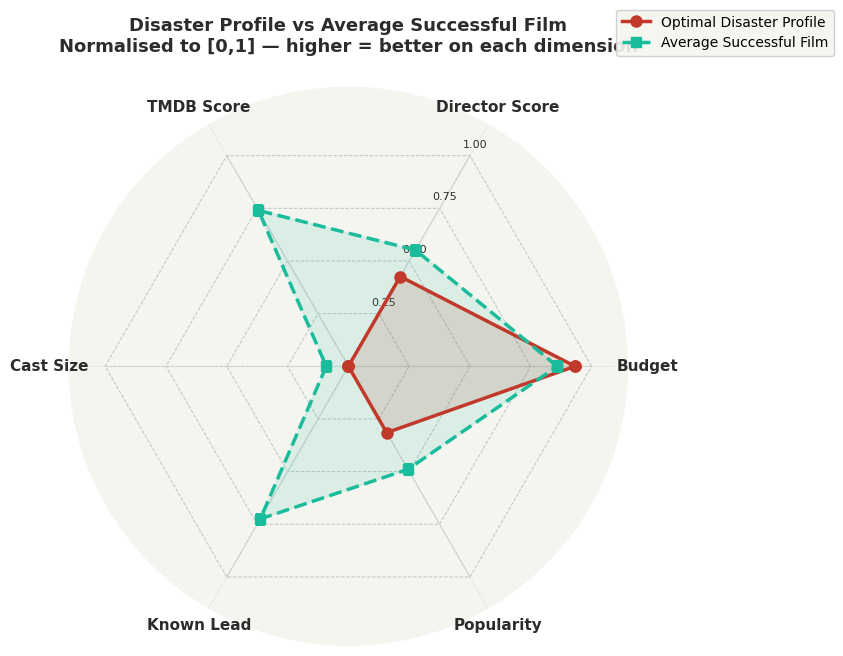

Saved: flop_fig5_radar.png


In [12]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

# Compare disaster profile against average successful film on 6 normalised dimensions
# Normalise each dimension to [0,1] where 1 = best possible (high = good)
KEY_DIMS = [
    ("log_budget",              "Budget",          False),   # False = low is worse
    ("director_success_score",  "Director Score",  False),
    ("vote_average_clean",      "TMDB Score",      False),
    ("cast_size_clean",         "Cast Size",       False),
    ("has_known_lead",          "Known Lead",      False),
    ("log_popularity",          "Popularity",      False),
]

DIMS   = [d[1] for d in KEY_DIMS]
N      = len(DIMS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def norm_vec(feat_indices, X, vec):
    vals   = X[:, feat_indices]
    lo, hi = vals.min(0), vals.max(0)
    rng    = np.where(hi - lo > 0, hi - lo, 1)
    return ((vec[feat_indices] - lo) / rng).tolist()

feat_idxs = [m4_feat_names.index(f[0]) for f in KEY_DIMS]

# Disaster profile (normalised)
disaster_norm_vals = norm_vec(feat_idxs, X_ref, disaster_vec) + [norm_vec(feat_idxs, X_ref, disaster_vec)[0]]

# Average successful film (top 30% by CSI)
key      = "M4_CSI"
y_train  = data[key]["y_train"]
X_m4     = data[key]["X_train"]
m4_names = data[key]["feature_names"]

success_mask = y_train == 1
X_success    = X_m4[success_mask]

# Map M4 features back to full feature space for these dims
success_means = []
for feat, _, _ in KEY_DIMS:
    if feat in m4_names:
        i = m4_names.index(feat)
        success_means.append(X_success[:, i].mean())
    else:
        success_means.append(np.median(X_ref[:, m4_feat_names.index(feat)]))

# Normalise success means using training distribution
success_norm = []
for val, (feat, _, _) in zip(success_means, KEY_DIMS):
    i  = m4_feat_names.index(feat)
    lo = X_ref[:, i].min()
    hi = X_ref[:, i].max()
    success_norm.append((val - lo) / (hi - lo) if hi > lo else 0.5)
success_norm += success_norm[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
fig.patch.set_facecolor("white")
ax.set_facecolor(CREAM)

# Reference rings
for r in [0.25, 0.5, 0.75, 1.0]:
    ax.plot(angles, [r]*(N+1), color=SILVER, linewidth=0.7, linestyle="--", zorder=1)
    ax.text(angles[1], r + 0.04, f"{r:.2f}", ha="center", fontsize=8, color=DARK_TEXT)

# Spokes
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, 1], color=SILVER, linewidth=0.8, zorder=1)

# Disaster profile
ax.plot(angles, disaster_norm_vals, color=CRIMSON, linewidth=2.5,
        marker="o", markersize=8, label="Optimal Disaster Profile", zorder=4)
ax.fill(angles, disaster_norm_vals, color=CRIMSON, alpha=0.15, zorder=3)

# Average success
ax.plot(angles, success_norm, color=TEAL, linewidth=2.5,
        marker="s", markersize=7, linestyle="--",
        label="Average Successful Film", zorder=4)
ax.fill(angles, success_norm, color=TEAL, alpha=0.12, zorder=3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(DIMS, fontsize=11, fontweight="bold", color=DARK_TEXT)
ax.set_yticks([])
ax.set_ylim(0, 1.15)
ax.set_title("""Disaster Profile vs Average Successful Film
Normalised to [0,1] — higher = better on each dimension""",
             fontsize=13, fontweight="bold", color=DARK_TEXT, pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.15), fontsize=10, framealpha=0.9)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("flop_fig5_radar.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: flop_fig5_radar.png")

## Figure 6 · Where the Disaster Sits in the Full Failure Distribution

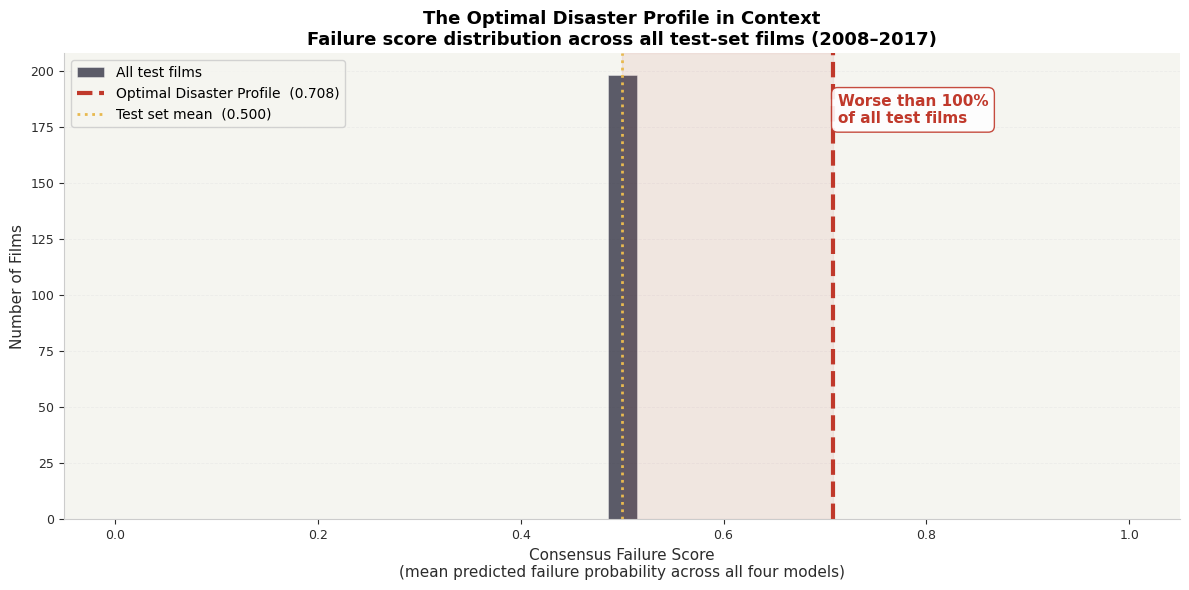

Saved: flop_fig6_failure_distribution.png


In [14]:
MIDNIGHT  = "#1a1a2e"
GOLD      = "#e8b94f"
CRIMSON   = "#c0392b"
SILVER    = "#bdc3c7"
CREAM     = "#f5f5f0"
DARK_TEXT = "#2c2c2c"
TEAL      = "#1abc9c"
PURPLE    = "#8e44ad"
FLOP_RED  = "#c0392b"
DISASTER  = "#7f0000"

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f5f5f0",
    "axes.edgecolor"   : "#2c2c2c",
    "axes.labelcolor"  : "#2c2c2c",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#2c2c2c",
    "ytick.color"      : "#2c2c2c",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "grid.color"       : "#e0e0e0",
    "grid.linestyle"   : "--",
    "grid.linewidth"   : 0.6,
    "legend.fontsize"  : 9,
    "font.family"      : "DejaVu Sans",
})

def style_spines(ax, keep=("bottom","left")):
    for spine in ax.spines.values():
        spine.set_visible(False)
    for s in keep:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_color("#cccccc")

fig, ax = plt.subplots(figsize=(12, 6))

all_scores = meta_test["failure_score"].values

ax.hist(all_scores, bins=35, color=MIDNIGHT, alpha=0.7,
        edgecolor="white", linewidth=0.4, label="All test films")

ax.axvline(disaster_score, color=CRIMSON, linewidth=3, linestyle="--",
           label=f"Optimal Disaster Profile  ({disaster_score:.3f})")
ax.axvline(all_scores.mean(), color=GOLD, linewidth=2, linestyle=":",
           label=f"Test set mean  ({all_scores.mean():.3f})")

pct_rank = (all_scores < disaster_score).mean() * 100
ax.text(disaster_score + 0.005, ax.get_ylim()[1] * 0.85,
        f"""Worse than {pct_rank:.0f}%
of all test films""",
        fontsize=11, color=CRIMSON, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=CRIMSON, alpha=0.9))

# Shade the extreme right tail
tail_x = np.linspace(disaster_score, all_scores.max(), 100)
ax.axvspan(disaster_score, all_scores.max(), alpha=0.08, color=CRIMSON)

ax.set_xlabel("""Consensus Failure Score
(mean predicted failure probability across all four models)""",
              fontsize=11)
ax.set_ylabel("Number of Films", fontsize=11)
ax.set_title("""The Optimal Disaster Profile in Context
Failure score distribution across all test-set films (2008–2017)""",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.85)
style_spines(ax)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("flop_fig6_failure_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: flop_fig6_failure_distribution.png")

## ✅ The Flop Formula Complete

### For the Newsletter — suggested tone and structure

**Opening:** Play it completely straight. *"Following four months of rigorous analysis
into what makes films successful, we present — as a public service to the industry —
the data-driven specification for the worst film Hollywood could possibly make."*

**The profile reveal:** Present the investment memo table (from NB_B1's output) as
though it were a genuine studio briefing. Let the numbers be funny on their own terms
without winking at the reader.

**Figure 1 (contributions):** *"These are the decisions that matter most. Ignore them."*

**Figure 2 (vs population):** *"For context, here is where each choice sits in the
historical distribution. The disaster profile is not merely bad — it is methodically,
specifically, precisely bad."*

**Figure 3 (gauges):** The investment memo panel. Four models, four verdicts,
one consensus. Let the failure percentages speak.

**Figure 4 (rogues gallery):** *"We cross-referenced the disaster profile against
real films from the test period. The following were identified as spiritually adjacent.
We will not be commenting further."*

**Figure 5 (radar):** The visual centrepiece — the disaster profile collapse vs the
successful film silhouette. Every axis, catastrophically inverted.

**Figure 6 (distribution):** The closing image. A histogram of all test films, the
disaster marker pushed to the extreme right tail, and a clean annotation: "Worse than
X% of all films in the dataset." The model has spoken.

**Sign-off:** *"The May series is complete. We have learned what makes films great,
who drives that greatness, whether audiences noticed, whether we could predict it —
and, finally, how to make something absolutely nobody should fund. We will see you
in June."*


In [15]:
print("The Flop Formula — all figures saved:")
for f in [
    "flop_fig1_failure_contributions.png",
    "flop_fig2_profile_vs_population.png",
    "flop_fig3_per_model_gauge.png",
    "flop_fig4_rogues_gallery.png",
    "flop_fig5_radar.png",
    "flop_fig6_failure_distribution.png",
]:
    print(f"  ✔  {f}")

print()
print("May series — complete.")
print("  Part 1 → What makes films financially successful?")
print("  Part 2 → Who drives that success?")
print("  Part 3 → Do audiences agree with the box office?")
print("  Part 4 → Can we predict success before it happens?")
print("  Bonus  → How do you engineer the perfect disaster?")


The Flop Formula — all figures saved:
  ✔  flop_fig1_failure_contributions.png
  ✔  flop_fig2_profile_vs_population.png
  ✔  flop_fig3_per_model_gauge.png
  ✔  flop_fig4_rogues_gallery.png
  ✔  flop_fig5_radar.png
  ✔  flop_fig6_failure_distribution.png

May series — complete.
  Part 1 → What makes films financially successful?
  Part 2 → Who drives that success?
  Part 3 → Do audiences agree with the box office?
  Part 4 → Can we predict success before it happens?
  Bonus  → How do you engineer the perfect disaster?
